In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd
import scarf
from scarf.agent import analyze_rna

scarf.configure_output(level="WARNING", progress=False)
source_path = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5", destination="scarf_datasets",
)[0]
teaching_directory = TemporaryDirectory(prefix="scarf-agent-teaching-")
zarr_path = Path(teaching_directory.name) / "analysis.zarr"
study_context = (
    "Human 10x Genomics 5K PBMC 3-prime gene expression from peripheral blood, "
    "collected from one healthy donor. The teaching cohort is a deterministic random "
    "subset of 1,000 cells (seed 42), not the full public dataset. "
    "No treatment comparison, trusted technical "
    "batch column, paired modality, or independent replication metadata is available. "
    "Do not invent missing design variables or report treatment effects."
)
source_path.name

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

'data.h5'

In [2]:
import json
from typing import Any

import numpy as np
from IPython import get_ipython
from pydantic_ai.messages import (
    ModelMessage,
    ModelResponse,
    ToolCallPart,
    ToolReturnPart,
)
from pydantic_ai.models.function import AgentInfo, FunctionModel

from scarf.agent.data_enrichment import (
    AssayFeatureInspectionBatch,
    DataEnrichmentReport,
    FeatureSelectionPolicy,
    StudyContextSummary,
)
from scarf.agent.experimental_context import (
    BatchCorrectionPlan,
    ExperimentalContextDecision,
)
from scarf.agent.ingest import ingest

prepared_input = ingest(path=source_path, zarrPath=zarr_path)
if prepared_input.status != "done":
    raise RuntimeError(f"Teaching dataset import failed: {prepared_input.notes}")
teaching_store = scarf.DataStore(
    str(zarr_path), min_features_per_cell=-1, mito_pattern="", ribo_pattern="",
)
teaching_store.cells.reset_key("I")
teaching_cells = np.zeros(teaching_store.cells.N, dtype=bool)
teaching_cells[np.random.default_rng(42).choice(teaching_store.cells.N, 1000, replace=False)] = True
teaching_store.cells.update_key(teaching_cells, "I")
source_path = zarr_path
del teaching_store

notebook_shell = get_ipython()
if notebook_shell is not None:
    notebook_shell.run_line_magic("matplotlib", "inline")

def _prompt_text(messages: list[ModelMessage]) -> str:
    values = []
    for message in messages:
        for part in message.parts:
            content = getattr(part, "content", None)
            if isinstance(content, str):
                values.append(content)
            elif isinstance(content, tuple):
                values.extend(item for item in content if isinstance(item, str))
    return "\n".join(values)


def _tool_result(
    messages: list[ModelMessage],
    tool_name: str,
    model_type: Any,
) -> Any:
    for message in reversed(messages):
        for part in reversed(message.parts):
            if isinstance(part, ToolReturnPart) and part.tool_name == tool_name:
                if isinstance(part.content, model_type):
                    return part.content
                if model_type is dict:
                    return json.loads(part.content) if isinstance(part.content, str) else part.content
                if isinstance(part.content, str):
                    return model_type.model_validate_json(part.content)
                return model_type.model_validate(part.content)
    raise AssertionError(f"Missing tool return {tool_name!r}")


def _tool_call(name: str, args: dict[str, Any] | None = None) -> ModelResponse:
    return ModelResponse(parts=[ToolCallPart(tool_name=name, args=args or {})])


def _structured_output(info: AgentInfo, value: Any) -> ModelResponse:
    payload = value.model_dump() if hasattr(value, "model_dump") else value
    return _tool_call(info.output_tools[0].name, payload)


def _scripted_workflow_model() -> tuple[FunctionModel, dict[str, Any]]:
    state = {
        "enrichment": 0,
        "context": 0,
        "parameter": 0,
        "assessments": [],
        "requests": 0,
    }

    async def reply(
        messages: list[ModelMessage],
        info: AgentInfo,
    ) -> ModelResponse:
        state["requests"] += 1
        tools = {tool.name for tool in info.function_tools}

        if (
            "inspect_assay_features_batch" in tools
            or state["enrichment"] == 1
            or any(
                tool.parameters_json_schema.get("title") == "DataEnrichmentReport"
                for tool in info.output_tools
            )
        ):
            if state["enrichment"] == 0:
                state["enrichment"] = 1
                return _tool_call("inspect_assay_features_batch")

            batch = _tool_result(
                messages,
                "inspect_assay_features_batch",
                AssayFeatureInspectionBatch,
            )
            policies = []
            for inspection in batch.inspections:
                species_observed = inspection.species != "unknown"
                policy_evidence = list(inspection.evidenceIds)
                if not species_observed:
                    policy_evidence.append("context:study")
                policies.append(
                    FeatureSelectionPolicy(
                        assay=inspection.assay,
                        species=(
                            inspection.species
                            if species_observed
                            else "homo_sapiens"
                        ),
                        speciesConfidence="high" if species_observed else "medium",
                        speciesRationale=(
                            inspection.speciesReason
                            or "The exact study paragraph identifies a human sample."
                        ),
                        excludeFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is True
                        ],
                        protectFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is False
                        ],
                        rationale=(
                            "Exclude observed technical families and preserve "
                            "observed protected families."
                        ),
                        evidenceIds=list(dict.fromkeys(policy_evidence)),
                    )
                )
            state["enrichment"] = 2
            return _structured_output(
                info,
                DataEnrichmentReport(
                    status="done",
                    studyContextSummary=StudyContextSummary(
                        organismReferences=["Human"],
                        tissueReferences=["peripheral blood"],
                        experimentalReferences=[
                            "10x Genomics 5K PBMC 3-prime gene expression"
                        ],
                        analysisIntentReferences=[
                            "Discover stable major immune-cell populations."
                        ],
                    ),
                    policies=policies,
                ),
            )

        if tools.intersection(
            {
                "inspect_cell_covariates",
                "analyze_experimental_design",
                "score_current_representation",
            }
        ) or state["context"] in {1, 2} or any(
            tool.parameters_json_schema.get("title") == "ExperimentalContextDecision"
            for tool in info.output_tools
        ):
            if state["context"] == 0:
                state["context"] = 1
                return _tool_call("inspect_cell_covariates")
            if state["context"] == 1:
                state["context"] = 2
                return _tool_call(
                    "analyze_experimental_design",
                    {
                        "column_domains": {},
                        "coefficients_of_interest": [],
                        "units_of_inference": {},
                        "batch_columns": [],
                    },
                )

            design = _tool_result(
                messages,
                "analyze_experimental_design",
                dict,
            )
            profile = next(
                value
                for value in design["qcProfiles"]
                if value["action"] == "skip"
            )
            evidence_id = profile["evidenceId"]
            state["context"] = 3
            return _structured_output(
                info,
                ExperimentalContextDecision(
                    batchCorrection=BatchCorrectionPlan(
                        action="skip",
                        rationale="No trusted technical batch column was supplied.",
                        evidenceIds=[evidence_id],
                    ),
                    rationale="No experimental covariates were supplied.",
                    evidenceIds=[evidence_id],
                ),
            )

        prompt = _prompt_text(messages)
        if any(
            {"selectedCandidateId", "comparisonConclusions"}.issubset(
                tool.parameters_json_schema.get("properties", {})
            )
            for tool in info.output_tools
        ):
            evidence, _ = json.JSONDecoder().raw_decode(prompt[prompt.index("{") :])
            coverage = evidence["comparisonCoverage"]
            settings = coverage["candidateSettings"]
            candidates = {
                item["candidateId"]: item for item in evidence["candidates"]
                if item["status"] == "done" and item["eligible"]
            }
            if not candidates:
                raise AssertionError("The teaching run has no supported partition")

            def rank(identity):
                metrics = settings[identity]["metrics"]
                return tuple(
                    float(metrics[name]) if metrics.get(name) is not None else -1.0
                    for name in ("seedStability", "markerCoherence")
                )

            axis_names = {
                "hvgCount": "variable-gene count", "hvgRanking": "gene ranking",
                "featurePolicy": "gene-family policy", "pca": "PCA dimensions",
                "neighbors": "neighbor count", "partition": "clustering resolution",
            }
            metric_names = {
                "seedStability": "agreement across clustering runs",
                "subsampleStability": "agreement after resampling",
                "markerCoherence": "the fraction of clusters with qualifying markers",
                "markerSpecificityMedian": "median marker specificity",
                "macroF1": "classification agreement",
            }
            axis_ids = {}
            for row in coverage["comparisons"]:
                identities = axis_ids.setdefault(row["axis"], [])
                for identity in (row["baselineCandidateId"], row["alternativeCandidateId"]):
                    if identity is not None and identity not in identities:
                        identities.append(identity)
            comparison_ids = {axis: list(identities) for axis, identities in axis_ids.items()}
            if coverage["phase"] != "sensitivity":
                axis_ids["partition"] = list(dict.fromkeys(
                    [*axis_ids["partition"], *coverage["resolutionCandidateIds"]]
                ))
            preferences = {axis: max(identities, key=rank) for axis, identities in axis_ids.items()}
            pending_policy = any(row["status"] == "pending" for row in coverage["comparisons"])
            experiment_id = None
            if coverage["phase"] == "sensitivity":
                selected_id = evidence["currentCandidateId"]
                action_name = "combine"
            else:
                eligible_resolutions = [
                    identity for identity in coverage["resolutionCandidateIds"]
                    if identity in candidates
                ]
                if not eligible_resolutions:
                    raise AssertionError("The combined representation has no supported partition")
                selected_id = max(eligible_resolutions, key=rank)
                preferences["partition"] = selected_id
                action_name = "accept"
            if pending_policy:
                families = evidence["featureEvidence"][selected_id]["families"]
                supported = [
                    (key, option) for key, option in evidence["experiments"].items()
                    if option["parameter"] in {"includeFamily", "excludeFamily"}
                    and families.get(option["value"], {}).get(
                        "selectedExamples" if option["parameter"] == "excludeFamily"
                        else "excludedExamples"
                    )
                ]
                if not supported:
                    raise AssertionError("The teaching policy has no observed family program to nominate")
                experiment_id, option = max(supported, key=lambda item: (
                    families[item[1]["value"]].get("selectedGenes", 0),
                    item[1]["affectedEligibleGenes"],
                ))
                action_name = "experiment"
            selected = candidates[selected_id]
            metrics = selected["metrics"]
            genes = list(dict.fromkeys(
                gene for names in metrics.get("topMarkerGenes", {}).values()
                for gene in names
            ))[:8]
            qualitative = (
                "The saved marker preview contains " + ", ".join(genes) + "."
                if genes else "The saved marker preview is empty; cell identities remain unresolved."
            )
            conclusions = []
            for axis, identities in axis_ids.items():
                preferred = preferences[axis]
                score = settings[preferred]["metrics"]
                conclusions.append({
                    "axis": axis,
                    "candidateIds": identities,
                    "preferredCandidateId": preferred,
                    "quantitativeReason": "; ".join(
                        f"Observed alternative {index + 1}: repeat agreement "
                        f"{settings[identity]['metrics'].get('seedStability')}, "
                        f"marker coverage {settings[identity]['metrics'].get('markerCoherence')}"
                        for index, identity in enumerate(identities)
                    ),
                    "biologicalReason": (
                        "This scripted teaching policy does not establish cell identities or "
                        "infer that a gene program is a technical artifact. " + qualitative
                    ),
                    "plainLanguageSummary": (
                        f"The teaching policy compared {len(identities)} observed {axis_names[axis]} "
                        f"settings and preferred repeat agreement {score.get('seedStability')}, "
                        f"using marker coverage {score.get('markerCoherence')} to break ties."
                    ),
                    "tradeoffs": [{
                        "alternativeCandidateId": identity,
                        "metric": metric,
                        "preferredValue": score[metric],
                        "alternativeValue": settings[identity]["metrics"][metric],
                        "interpretation": (
                            f"An alternative has higher {metric_names[metric]} "
                            f"({settings[identity]['metrics'][metric]} versus {score[metric]}). "
                            "The teaching policy prioritizes repeat agreement, then marker coverage; "
                            "this loss remains an explicit limit of its choice."
                        ),
                    } for identity in comparison_ids[axis] if identity != preferred
                        for metric in ("seedStability", "subsampleStability", "markerCoherence",
                                       "markerSpecificityMedian", "macroF1")
                        if isinstance(score.get(metric), (int, float))
                        and isinstance(settings[identity]["metrics"].get(metric), (int, float))
                        and settings[identity]["metrics"][metric] > score[metric]],
                })
            quantitative = (
                f"Observed resolution {selected['parameters']['leidenResolution']} has "
                f"repeat agreement {metrics.get('seedStability')} and marker coverage "
                f"{metrics.get('markerCoherence')}."
            )
            summary = (
                "The teaching policy proposes testing a represented gene family; "
                "its contribution must be measured before retaining or changing the gene selection."
                if action_name == "experiment" else
                "The teaching policy proposes a combination of the observed settings; "
                "Scarf must execute that combination and compare its four resolutions."
                if action_name == "combine" else
                "The teaching policy selected the measured combined representation and "
                "its most repeatable eligible partition. Marker identities remain unvalidated."
            )
            action = {
                "action": action_name,
                "selectedCandidateId": selected_id,
                "experimentId": experiment_id,
                "correctionNeed": "notApplicable",
                "comparisonConclusions": conclusions,
                "plainLanguageSummary": summary,
                "evidenceIds": [
                    f"candidate:{selected_id}",
                    *list(evidence["imageHashes"])[:1],
                    "studyContract", "qcPolicy", "samplingCoverage", "featureEvidence",
                ],
                "quantitativeFindings": [quantitative],
                "qualitativeFindings": [qualitative],
                "objectivePreservation": (
                    "Preserve the single-donor population structure and retain marker "
                    "uncertainty; no batch or treatment comparison is supported."
                ),
                "rationale": summary + " " + quantitative,
                "concern": (
                    f"Observed family {option['value']} contains "
                    f"{families[option['value']].get('selectedGenes', 0)} selected genes. "
                    "Test sensitivity to this program without assuming that it is technical."
                ) if pending_policy else "",
                "expectedImprovement": (
                    "Measure whether changing this gene-family selection preserves the major "
                    "marker programs and improves repeat agreement."
                ) if pending_policy else "",
                "populationConcerns": [{
                    "candidateId": selected_id,
                    "clusterId": cluster,
                    "status": "nonEssentialLimitation",
                    "evidenceIds": [f"candidate:{selected_id}"],
                    "explanation": (
                        f"Population {cluster} has no qualifying marker genes and remains unclassified. "
                        "This tutorial demonstrates selecting analysis settings; it does not validate "
                        "cell identities or claim that every population has been biologically resolved."
                    ),
                } for cluster, names in metrics.get("topMarkerGenes", {}).items() if not names],
            }
            if action_name == "combine":
                action["combinedSettings"] = {
                    field: preferences[axis] for field, axis in (
                        ("hvgCountCandidateId", "hvgCount"),
                        ("hvgRankingCandidateId", "hvgRanking"),
                        ("featurePolicyCandidateId", "featurePolicy"),
                        ("pcaCandidateId", "pca"),
                        ("neighborsCandidateId", "neighbors"),
                    )
                }
            state["assessments"].append({
                "selection": action,
                "alternatives": [{
                    "resolution": settings[identity]["parameters"]["leidenResolution"],
                    "clusters": settings[identity]["metrics"].get("nClusters"),
                    "repeat_agreement": settings[identity]["metrics"].get("seedStability"),
                    "clusters_with_markers": settings[identity]["metrics"].get("markerCoherence"),
                    "selected": identity == selected_id,
                } for identity in (
                    coverage["resolutionCandidateIds"] if action_name == "accept"
                    else list(candidates)
                )],
            })
            return _structured_output(info, action)


        payload, _ = json.JSONDecoder().raw_decode(prompt[prompt.index("{") :])
        decision = payload["spec"]
        evidence_by_class = {}
        evidence_class_by_id = {}
        for item in payload["evidence"]["evidence"]:
            evidence_by_class.setdefault(
                item["evidenceClass"],
                item["evidenceId"],
            )
            evidence_class_by_id[item["evidenceId"]] = item["evidenceClass"]
        preferred = decision.get("metricPreferredOptionId")
        selected = (
            next(
                option
                for option in decision["options"]
                if option["optionId"] == preferred
            )
            if preferred is not None
            else next(
                option
                for option in decision["options"]
                if option["status"] in {"apply", "skip"}
            )
        )
        evidence_ids = list(selected.get("requiredEvidenceIds", []))
        cited_classes = {
            evidence_class_by_id[evidence_id] for evidence_id in evidence_ids
        }
        for evidence_class in selected["requiredEvidenceClasses"]:
            if evidence_class not in cited_classes:
                evidence_ids.append(evidence_by_class[evidence_class])
        state["parameter"] += 1
        return _structured_output(
            info,
            dict(
                selectedOptionId=selected["optionId"],
                evidenceIds=evidence_ids,
                rationale=f"Use the offered {selected['label']} policy with its required observed evidence.",
                confidence="high",
            ),
        )

    return FunctionModel(reply), state

model, model_state = _scripted_workflow_model()

In [3]:
result = analyze_rna(
    source_path,
    model=model,
    study_context=study_context,
    study_objective="Discover stable major immune-cell populations.",
    score_doublets=False,
)
{"status": result.status}

{'status': 'completed'}

In [4]:
assessment = model_state["assessments"][-1]
pd.DataFrame(assessment["alternatives"])

,resolution,clusters,repeat_agreement,clusters_with_markers,selected
0,0.50,6,0.998637,1.0,True
1,0.75,6,0.936865,1.0,False
2,1.00,9,0.859500,1.0,False
3,1.25,12,0.701969,1.0,False


In [5]:
selection = assessment["selection"]
{
    "Why this setting": selection["rationale"],
    "Marker evidence": selection["qualitativeFindings"],
    "Biology to preserve": selection["objectivePreservation"],
}

{'Why this setting': 'The teaching policy selected the measured combined representation and its most repeatable eligible partition. Marker identities remain unvalidated. Observed resolution 0.5 has repeat agreement 0.9986374928315574 and marker coverage 1.0.',
 'Marker evidence': ['The saved marker preview contains GZMK, AQP3, NSG1, NPDC1, TNFRSF4, IL7R, LMNA, TNFRSF25.'],
 'Biology to preserve': 'Preserve the single-donor population structure and retain marker uncertainty; no batch or treatment comparison is supported.'}

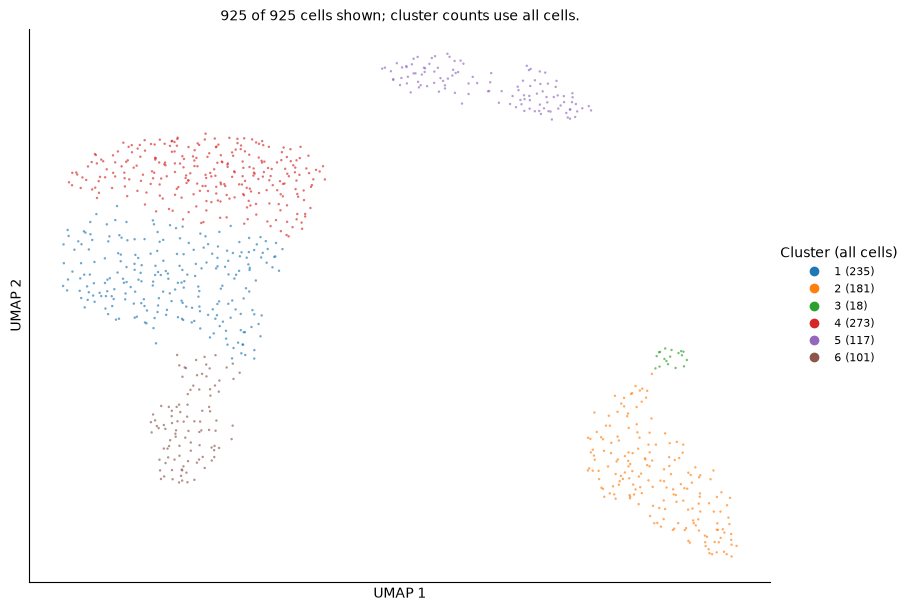

In [6]:
result.plot_embedding(figsize=(9, 6))

In [7]:
marker_table = result.get_markers()
marker_table.sort_values(
    ["group_id", "score"], ascending=[True, False],
).groupby("group_id", sort=True).head(2)[
    ["group_id", "feature_name", "score", "frac_exp"]
].head(12)

,group_id,feature_name,score,frac_exp
0,1,GZMK,0.60678,0.40851
1,1,AQP3,0.59391,0.51915
242,2,S100A12,0.93705,0.94475
243,2,VCAN,0.92812,0.98343
1543,3,TCF7L2,0.78348,1.00000
1544,3,CTSL,0.75346,0.72222
2724,4,LRRN3,0.80702,0.52381
2725,4,FHIT,0.71353,0.54945
3110,5,BANK1,0.91515,0.94017
3111,5,MS4A1,0.91074,0.95726


In [8]:
report_path = result.report()
{"report": report_path.name, "exists": report_path.is_file()}

{'report': 'index.html', 'exists': True}